# Heart Disease — Feature Engineering & Model Development

**Course**: MLOps (S2-25_AMLCSZG523) — Assignment-I, Task 2 (8 marks) + Task 3 (5 marks)

Builds on `01_eda.ipynb`. Goals:

1. Lock in a single, leakage-free preprocessing pipeline (`SimpleImputer` → `StandardScaler` for numeric + `OneHotEncoder` for categoricals).
2. Train **Logistic Regression** and **Random Forest** classifiers, with light hyperparameter tuning via `GridSearchCV`.
3. Evaluate every candidate with 5-fold stratified CV (accuracy, precision, recall, F1, ROC-AUC).
4. **Three-way data split** for trustworthy generalization estimates:
   - **Cleveland train (80%)** — used for CV-based hyperparameter search.
   - **Cleveland test (20%)** — held-out, same-site sanity check.
   - **Hungarian (`processed.hungarian.data`, 294 rows)** — completely external dataset (different hospital), used as **out-of-distribution validation**. The model never sees this data during training or selection; it's the most honest signal of how the system would behave in production at a new site.
5. Log each candidate as its **own MLflow run** under separate parent runs (`logreg`, `randomforest`) so the experiment evolution is fully traceable.

MLflow layout for this notebook:

```
experiment: heart-disease-modeling
├── parent run: logreg
│   ├── child run: logreg_C=0.01 ...
│   ├── child run: logreg_C=0.1 ...
│   └── child run: logreg_best (refit + cleveland-test + hungarian-val + model artifact)
└── parent run: randomforest
    ├── child run: rf_n=200_depth=4 ...
    ├── ...
    └── child run: rf_best (refit + cleveland-test + hungarian-val + model artifact)
```

Run `mlflow ui --backend-store-uri ./mlruns` from the `project/` folder to compare runs interactively.

## 1. Imports, paths, and MLflow setup

We mirror the conventions from `01_eda.ipynb`: pinned `RANDOM_STATE`, file-based MLflow store under `project/mlruns/`.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed.cleveland.data"
ARTIFACTS_DIR = PROJECT_ROOT / "notebooks" / "modeling_artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

MLRUNS_URI = (PROJECT_ROOT / "mlruns").as_uri()
mlflow.set_tracking_uri(MLRUNS_URI)
mlflow.set_experiment("heart-disease-modeling")

print("Data file        :", DATA_PATH, "exists?", DATA_PATH.exists())
print("MLflow tracking  :", mlflow.get_tracking_uri())
print("Active experiment:", mlflow.get_experiment_by_name("heart-disease-modeling").name)

2026/04/25 23:02:09 INFO mlflow.tracking.fluent: Experiment with name 'heart-disease-modeling' does not exist. Creating a new experiment.


Data file        : /Users/ajoish/Library/CloudStorage/OneDrive-Cisco/Documents/MTech/SEM 2/MLOps/Assignment/project/data/processed.cleveland.data exists? True
MLflow tracking  : file:///Users/ajoish/Library/CloudStorage/OneDrive-Cisco/Documents/MTech/SEM%202/MLOps/Assignment/project/mlruns
Active experiment: heart-disease-modeling


## 2. Load data + three-way split

We re-read the raw `processed.cleveland.data` (rather than the EDA-cleaned CSV) because the imputers belong **inside** the modeling `Pipeline` — that's the only way to guarantee zero train/test leakage and a single picklable artifact for the FastAPI container later.

The Hungarian file (`processed.hungarian.data`, same 14-column schema) is loaded as a fully **external validation set**. It comes from a different hospital, has its own missing-value pattern, and our model will never see it during training or hyperparameter selection — it's the cleanest available proxy for production drift.

- Cleveland train (80%, stratified) → CV grid search.
- Cleveland test (20%, stratified) → same-site held-out check.
- Hungarian (294 rows, all imputed by the in-pipeline `SimpleImputer`) → external (out-of-distribution) validation.

In [2]:
COLUMNS = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num",
]
CATEGORICAL = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
NUMERIC = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
FEATURES = NUMERIC + CATEGORICAL


def load_processed(path: Path) -> pd.DataFrame:
    """Load any UCI processed.<site>.data file with the canonical schema."""
    frame = pd.read_csv(path, header=None, names=COLUMNS, na_values="?")
    frame["target"] = (frame["num"] > 0).astype(int)
    return frame


# ---- Cleveland (training site) ----
df_cleveland = load_processed(DATA_PATH)
X = df_cleveland[FEATURES].copy()
y = df_cleveland["target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)

# ---- Hungarian (external validation site) ----
HUNGARIAN_PATH = PROJECT_ROOT / "data" / "processed.hungarian.data"
df_hungarian = load_processed(HUNGARIAN_PATH)
X_val = df_hungarian[FEATURES].copy()
y_val = df_hungarian["target"].copy()

print(f"Cleveland train: {X_train.shape}, positive rate = {y_train.mean():.3f}")
print(f"Cleveland test : {X_test.shape}, positive rate = {y_test.mean():.3f}")
print(f"Hungarian val  : {X_val.shape}, positive rate = {y_val.mean():.3f}")
print(f"\nHungarian missing per column (handled by pipeline imputers):")
print(X_val.isna().sum()[X_val.isna().sum() > 0])

Cleveland train: (242, 13), positive rate = 0.459
Cleveland test : (61, 13), positive rate = 0.459
Hungarian val  : (294, 13), positive rate = 0.361

Hungarian missing per column (handled by pipeline imputers):
trestbps      1
chol         23
thalach       1
ca          291
fbs           8
restecg       1
exang         1
slope       190
thal        266
dtype: int64


## 3. Shared preprocessing pipeline

One `ColumnTransformer` handles both numeric and categorical branches:

- **Numeric**: median imputation → standard scaling.
- **Categorical**: most-frequent imputation → one-hot encoding (with `handle_unknown="ignore"` so the served API never crashes on an unseen category).

Random Forest doesn't need scaling but it doesn't hurt — keeping a single preprocessor simplifies the code and the model artifact.

In [3]:
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, NUMERIC),
    ("cat", categorical_pipe, CATEGORICAL),
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 4. Helpers — metrics, plots, MLflow logging

The two model families share the same evaluation surface, so we factor it into helpers used by both training blocks. Every helper writes both to disk (under `notebooks/modeling_artifacts/`) and to the active MLflow run.

In [4]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}


def compute_metrics(model, X_eval: pd.DataFrame, y_eval: pd.Series, prefix: str) -> dict:
    """Standard binary-classification metrics on any held-out set.

    `prefix` is prepended to every metric name so MLflow can store
    e.g. test_roc_auc and val_roc_auc side-by-side.
    """
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    return {
        f"{prefix}_accuracy": accuracy_score(y_eval, y_pred),
        f"{prefix}_precision": precision_score(y_eval, y_pred),
        f"{prefix}_recall": recall_score(y_eval, y_pred),
        f"{prefix}_f1": f1_score(y_eval, y_pred),
        f"{prefix}_roc_auc": roc_auc_score(y_eval, y_proba),
    }


def log_confusion_matrix(model, X_eval, y_eval, out_name: str, split_label: str = "test") -> Path:
    cm = confusion_matrix(y_eval, model.predict(X_eval))
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=["no disease", "disease"],
        yticklabels=["no disease", "disease"], ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion matrix — {out_name} ({split_label})")
    out = ARTIFACTS_DIR / f"cm_{out_name}_{split_label}.png"
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.show()
    mlflow.log_artifact(str(out), artifact_path="plots")
    return out


def log_roc_curve(model, X_eval, y_eval, out_name: str, split_label: str = "test") -> Path:
    y_proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_eval, y_proba)
    auc = roc_auc_score(y_eval, y_proba)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="#D7263D")
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title(f"ROC curve — {out_name} ({split_label})")
    ax.legend(loc="lower right")
    out = ARTIFACTS_DIR / f"roc_{out_name}_{split_label}.png"
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.show()
    mlflow.log_artifact(str(out), artifact_path="plots")
    return out


def log_classification_report(model, X_eval, y_eval, out_name: str, split_label: str = "test") -> Path:
    report = classification_report(
        y_eval, model.predict(X_eval),
        target_names=["no_disease", "disease"], digits=3,
    )
    out = ARTIFACTS_DIR / f"report_{out_name}_{split_label}.txt"
    out.write_text(report)
    mlflow.log_artifact(str(out), artifact_path="reports")
    print(f"\n--- {out_name} on {split_label} ---")
    print(report)
    return out

In [5]:
def run_grid_with_per_candidate_logging(
    model_family: str,
    estimator,
    param_grid: dict,
    X_tr: pd.DataFrame,
    y_tr: pd.Series,
    X_te: pd.DataFrame,
    y_te: pd.Series,
    X_va: pd.DataFrame,
    y_va: pd.Series,
) -> tuple[Pipeline, pd.DataFrame, str]:
    """
    Train one model family end-to-end with full MLflow traceability:

    - Opens a parent MLflow run named after the family (e.g. "logreg").
    - Runs GridSearchCV with 5-fold StratifiedKFold scoring on accuracy/
      precision/recall/f1/roc_auc.
    - Logs ONE child run per hyperparameter candidate, capturing CV mean +
      std for every metric → makes hyperparameter evolution comparable in
      the MLflow UI.
    - Logs a final "<family>_best" child run with the refitted estimator,
      Cleveland-test metrics, Hungarian external-validation metrics, plots,
      classification reports, and the model itself via mlflow.sklearn.log_model
      so it can be served from Docker.
    """
    pipe = Pipeline([("prep", preprocessor), ("clf", estimator)])

    grid = GridSearchCV(
        pipe, param_grid=param_grid,
        scoring=SCORING, refit="roc_auc",
        cv=CV, n_jobs=-1, return_train_score=False,
    )

    with mlflow.start_run(run_name=model_family) as parent:
        mlflow.set_tag("model_family", model_family)
        mlflow.log_params({
            "cv_folds": CV.get_n_splits(),
            "n_train": len(X_tr),
            "n_test": len(X_te),
            "n_val_external": len(X_va),
            "val_source": "processed.hungarian.data",
            "random_state": RANDOM_STATE,
            "refit_metric": "roc_auc",
        })

        grid.fit(X_tr, y_tr)

        # ---- One child run per hyperparameter candidate ----
        cv_results = pd.DataFrame(grid.cv_results_).sort_values(
            "mean_test_roc_auc", ascending=False,
        )
        for _, row in cv_results.iterrows():
            params = row["params"]
            child_name = f"{model_family}_" + "_".join(
                f"{k.split('__')[-1]}={v}" for k, v in params.items()
            )
            with mlflow.start_run(run_name=child_name, nested=True):
                mlflow.set_tag("model_family", model_family)
                mlflow.set_tag("stage", "cv_candidate")
                mlflow.log_params(params)
                for metric in SCORING:
                    mlflow.log_metric(f"cv_{metric}_mean", row[f"mean_test_{metric}"])
                    mlflow.log_metric(f"cv_{metric}_std", row[f"std_test_{metric}"])
                mlflow.log_metric("cv_fit_time_mean", row["mean_fit_time"])

        # ---- Save the full CV results table as an artifact on the parent ----
        cv_csv = ARTIFACTS_DIR / f"cv_results_{model_family}.csv"
        cv_results.to_csv(cv_csv, index=False)
        mlflow.log_artifact(str(cv_csv), artifact_path="cv")

        # ---- Best-candidate child run with full evaluation + model artifact ----
        best_params = grid.best_params_
        best_model = grid.best_estimator_
        with mlflow.start_run(run_name=f"{model_family}_best", nested=True) as best_run:
            mlflow.set_tag("model_family", model_family)
            mlflow.set_tag("stage", "best")
            mlflow.log_params(best_params)
            # CV scores (best row)
            best_row = cv_results.iloc[0]
            for metric in SCORING:
                mlflow.log_metric(f"cv_{metric}_mean", best_row[f"mean_test_{metric}"])
                mlflow.log_metric(f"cv_{metric}_std", best_row[f"std_test_{metric}"])

            # Cleveland-test (same-site held-out)
            test_metrics = compute_metrics(best_model, X_te, y_te, prefix="test")
            mlflow.log_metrics(test_metrics)
            log_confusion_matrix(best_model, X_te, y_te, model_family, split_label="test")
            log_roc_curve(best_model, X_te, y_te, model_family, split_label="test")
            log_classification_report(best_model, X_te, y_te, model_family, split_label="test")

            # Hungarian (external out-of-distribution validation)
            val_metrics = compute_metrics(best_model, X_va, y_va, prefix="val")
            mlflow.log_metrics(val_metrics)
            log_confusion_matrix(best_model, X_va, y_va, model_family, split_label="val_hungarian")
            log_roc_curve(best_model, X_va, y_va, model_family, split_label="val_hungarian")
            log_classification_report(best_model, X_va, y_va, model_family, split_label="val_hungarian")

            # Generalization gap (test vs external val) — useful to spot drift
            gap_metrics = {
                f"gap_{m}": test_metrics[f"test_{m}"] - val_metrics[f"val_{m}"]
                for m in ("roc_auc", "f1", "accuracy")
            }
            mlflow.log_metrics(gap_metrics)

            # Persisted model (deployable artifact)
            mlflow.sklearn.log_model(
                sk_model=best_model,
                name="model",
                input_example=X_tr.head(3),
                registered_model_name=None,  # registry not used in Task 4 scope
            )
            best_run_id = best_run.info.run_id

        # ---- Surface the headline numbers on the parent run too ----
        mlflow.log_params({f"best_{k}": v for k, v in best_params.items()})
        mlflow.log_metric("best_cv_roc_auc", grid.best_score_)
        for k, v in test_metrics.items():
            mlflow.log_metric(f"best_{k}", v)
        for k, v in val_metrics.items():
            mlflow.log_metric(f"best_{k}", v)

        print(f"\n[{model_family}] best params: {best_params}")
        print(f"[{model_family}] best CV ROC-AUC : {grid.best_score_:.4f}")
        print(f"[{model_family}] cleveland test  : {test_metrics}")
        print(f"[{model_family}] hungarian val   : {val_metrics}")
        print(f"[{model_family}] generalization gap (test - val): {gap_metrics}")
        print(f"[{model_family}] parent run id   : {parent.info.run_id}")
        print(f"[{model_family}] best run id     : {best_run_id}")

    return best_model, cv_results, best_run_id

## 5. Logistic Regression

Grid covers L1 + L2 regularization at four `C` strengths. `liblinear` solver supports both penalties on this dataset size.

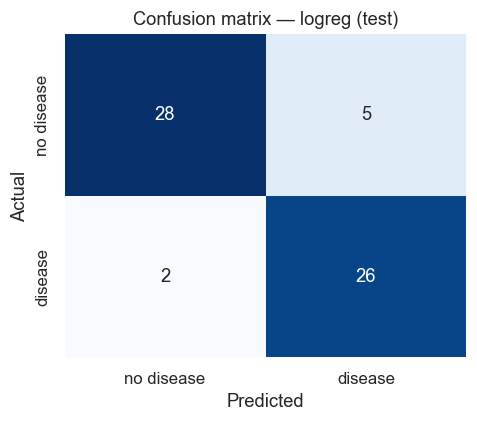

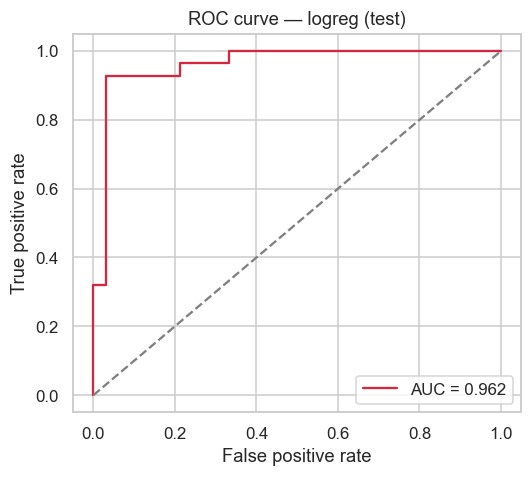


--- logreg on test ---
              precision    recall  f1-score   support

  no_disease      0.933     0.848     0.889        33
     disease      0.839     0.929     0.881        28

    accuracy                          0.885        61
   macro avg      0.886     0.889     0.885        61
weighted avg      0.890     0.885     0.885        61



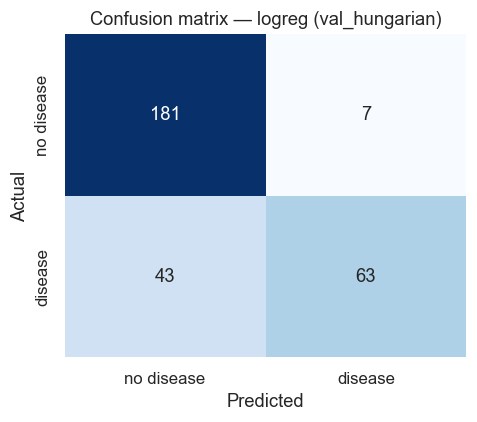

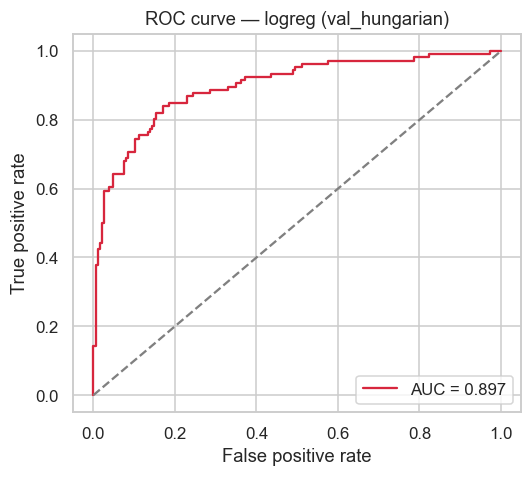


--- logreg on val_hungarian ---
              precision    recall  f1-score   support

  no_disease      0.808     0.963     0.879       188
     disease      0.900     0.594     0.716       106

    accuracy                          0.830       294
   macro avg      0.854     0.779     0.797       294
weighted avg      0.841     0.830     0.820       294



2026/04/25 23:02:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



[logreg] best params: {'clf__C': 0.1, 'clf__penalty': 'l2'}
[logreg] best CV ROC-AUC : 0.9117
[logreg] cleveland test  : {'test_accuracy': 0.8852459016393442, 'test_precision': 0.8387096774193549, 'test_recall': 0.9285714285714286, 'test_f1': 0.8813559322033898, 'test_roc_auc': 0.9621212121212122}
[logreg] hungarian val   : {'val_accuracy': 0.8299319727891157, 'val_precision': 0.9, 'val_recall': 0.5943396226415094, 'val_f1': 0.7159090909090909, 'val_roc_auc': 0.8967282215977518}
[logreg] generalization gap (test - val): {'gap_roc_auc': 0.06539299052346037, 'gap_f1': 0.16544684129429887, 'gap_accuracy': 0.055313928850228566}
[logreg] parent run id   : b03c552ece49401e92ff8304fb205b47
[logreg] best run id     : 0c8992977528404a967508bc82c24f50


,params,mean_test_roc_auc,std_test_roc_auc,mean_test_f1,mean_test_accuracy
3,"{'clf__C': 0.1, 'clf__penalty': 'l2'}",0.911694,0.017387,0.826155,0.846939
4,"{'clf__C': 1.0, 'clf__penalty': 'l1'}",0.909669,0.012167,0.821590,0.842772
5,"{'clf__C': 1.0, 'clf__penalty': 'l2'}",0.906495,0.019166,0.825353,0.847024
6,"{'clf__C': 10.0, 'clf__penalty': 'l1'}",0.904527,0.014581,0.836543,0.855187
7,"{'clf__C': 10.0, 'clf__penalty': 'l2'}",0.904514,0.015750,0.832594,0.851020
1,"{'clf__C': 0.01, 'clf__penalty': 'l2'}",0.897313,0.025366,0.779092,0.813946
2,"{'clf__C': 0.1, 'clf__penalty': 'l1'}",0.883864,0.021102,0.784704,0.818112
0,"{'clf__C': 0.01, 'clf__penalty': 'l1'}",0.500000,0.000000,0.000000,0.541327


In [6]:
lr_grid = {
    "clf__C": [0.01, 0.1, 1.0, 10.0],
    "clf__penalty": ["l1", "l2"],
}

lr_estimator = LogisticRegression(
    solver="liblinear", max_iter=1000, random_state=RANDOM_STATE,
)

lr_best_model, lr_cv_results, lr_best_run_id = run_grid_with_per_candidate_logging(
    model_family="logreg",
    estimator=lr_estimator,
    param_grid=lr_grid,
    X_tr=X_train, y_tr=y_train,
    X_te=X_test, y_te=y_test,
    X_va=X_val, y_va=y_val,
)

lr_cv_results[[
    "params", "mean_test_roc_auc", "std_test_roc_auc",
    "mean_test_f1", "mean_test_accuracy",
]].head(8)

## 6. Random Forest

Shallow trees + small `min_samples_leaf` to control overfitting on 240 training rows.

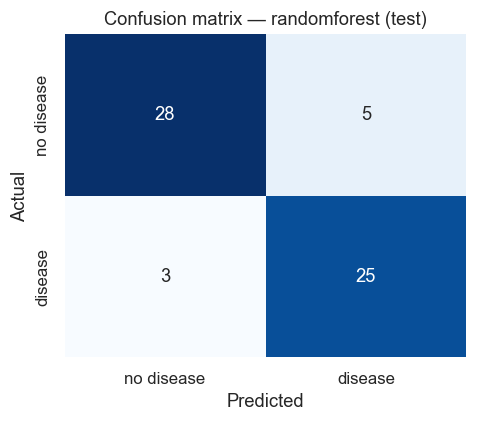

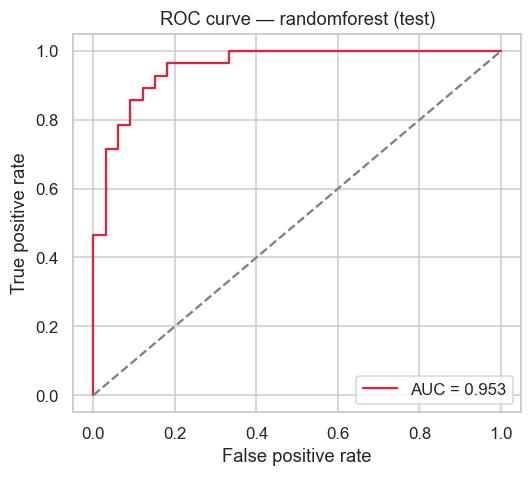


--- randomforest on test ---
              precision    recall  f1-score   support

  no_disease      0.903     0.848     0.875        33
     disease      0.833     0.893     0.862        28

    accuracy                          0.869        61
   macro avg      0.868     0.871     0.869        61
weighted avg      0.871     0.869     0.869        61



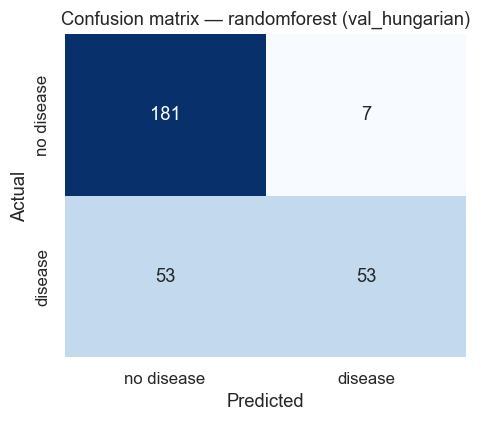

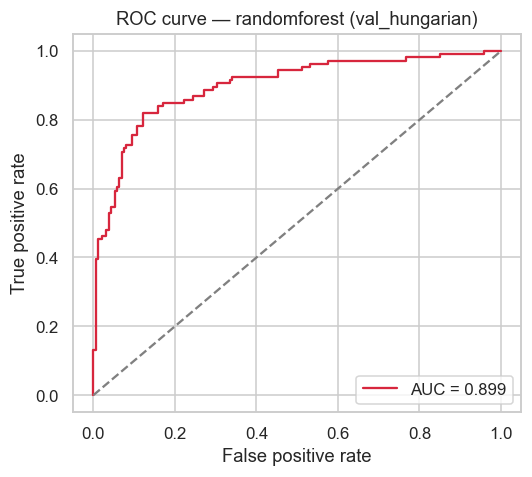

2026/04/25 23:02:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



--- randomforest on val_hungarian ---
              precision    recall  f1-score   support

  no_disease      0.774     0.963     0.858       188
     disease      0.883     0.500     0.639       106

    accuracy                          0.796       294
   macro avg      0.828     0.731     0.748       294
weighted avg      0.813     0.796     0.779       294


[randomforest] best params: {'clf__max_depth': 4, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 400}
[randomforest] best CV ROC-AUC : 0.8996
[randomforest] cleveland test  : {'test_accuracy': 0.8688524590163934, 'test_precision': 0.8333333333333334, 'test_recall': 0.8928571428571429, 'test_f1': 0.8620689655172413, 'test_roc_auc': 0.9534632034632036}
[randomforest] hungarian val   : {'val_accuracy': 0.7959183673469388, 'val_precision': 0.8833333333333333, 'val_recall': 0.5, 'val_f1': 0.6385542168674698, 'val_roc_auc': 0.8985347250100362}
[randomforest] generalization gap (test - val): {'gap_roc_auc': 0.054928478453167395, '

,params,mean_test_roc_auc,std_test_roc_auc,mean_test_f1,mean_test_accuracy
3,"{'clf__max_depth': 4, 'clf__min_samples_leaf':...",0.899552,0.025993,0.783342,0.809779
2,"{'clf__max_depth': 4, 'clf__min_samples_leaf':...",0.898863,0.026101,0.790783,0.818112
4,"{'clf__max_depth': 4, 'clf__min_samples_leaf':...",0.898766,0.030119,0.784205,0.809609
9,"{'clf__max_depth': 6, 'clf__min_samples_leaf':...",0.898470,0.030327,0.790188,0.813861
23,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.898041,0.032413,0.780634,0.805527
17,"{'clf__max_depth': 8, 'clf__min_samples_leaf':...",0.898041,0.032413,0.780634,0.805527
21,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.897786,0.030096,0.781051,0.805612
6,"{'clf__max_depth': 6, 'clf__min_samples_leaf':...",0.897644,0.025926,0.792198,0.818027


In [7]:
rf_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [4, 6, 8, None],
    "clf__min_samples_leaf": [1, 3, 5],
}

rf_estimator = RandomForestClassifier(
    random_state=RANDOM_STATE, n_jobs=-1,
)

rf_best_model, rf_cv_results, rf_best_run_id = run_grid_with_per_candidate_logging(
    model_family="randomforest",
    estimator=rf_estimator,
    param_grid=rf_grid,
    X_tr=X_train, y_tr=y_train,
    X_te=X_test, y_te=y_test,
    X_va=X_val, y_va=y_val,
)

rf_cv_results[[
    "params", "mean_test_roc_auc", "std_test_roc_auc",
    "mean_test_f1", "mean_test_accuracy",
]].head(8)

## 7. Side-by-side comparison

We pull the parent-run metrics for both families directly out of MLflow so the comparison table reflects exactly what's stored in `mlruns/`. This is the table we'll cite in the report when justifying the production model choice.

In [8]:
comparison_rows = []
for family, best_model, best_run_id in [
    ("logreg", lr_best_model, lr_best_run_id),
    ("randomforest", rf_best_model, rf_best_run_id),
]:
    row = {"model_family": family, "best_run_id": best_run_id}
    row.update(compute_metrics(best_model, X_test, y_test, prefix="test"))
    row.update(compute_metrics(best_model, X_val, y_val, prefix="val"))
    comparison_rows.append(row)

comparison = (
    pd.DataFrame(comparison_rows)
    .set_index("model_family")
    [[
        "test_roc_auc", "val_roc_auc",
        "test_f1", "val_f1",
        "test_accuracy", "val_accuracy",
        "test_precision", "val_precision",
        "test_recall", "val_recall",
        "best_run_id",
    ]]
    .sort_values("val_roc_auc", ascending=False)
)

comparison_path = ARTIFACTS_DIR / "model_comparison.csv"
comparison.to_csv(comparison_path)
print(f"Saved {comparison_path}")
comparison

Saved /Users/ajoish/Library/CloudStorage/OneDrive-Cisco/Documents/MTech/SEM 2/MLOps/Assignment/project/notebooks/modeling_artifacts/model_comparison.csv


,test_roc_auc,val_roc_auc,test_f1,val_f1,test_accuracy,val_accuracy,test_precision,val_precision,test_recall,val_recall,best_run_id
model_family,,,,,,,,,,,
randomforest,0.953463,0.898535,0.862069,0.638554,0.868852,0.795918,0.833333,0.883333,0.892857,0.50000,88abf05dd8bd49c289d0c90faeed9ab8
logreg,0.962121,0.896728,0.881356,0.715909,0.885246,0.829932,0.838710,0.900000,0.928571,0.59434,0c8992977528404a967508bc82c24f50


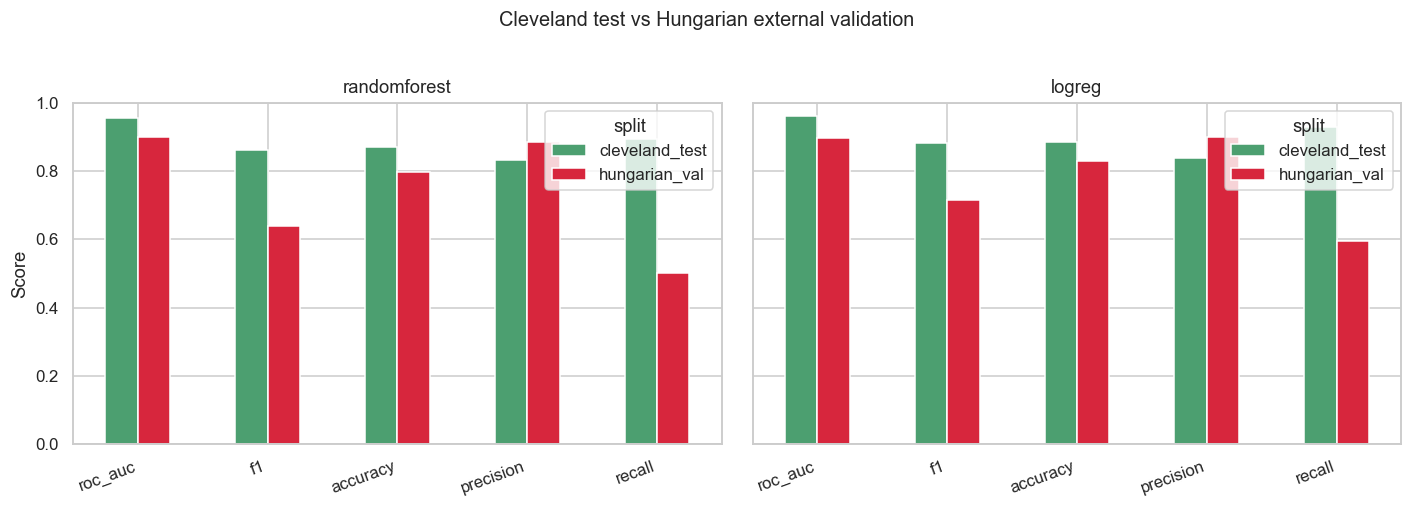

In [9]:
# Visual side-by-side: bar chart of Cleveland-test vs Hungarian-val metrics per family
metric_names = ["roc_auc", "f1", "accuracy", "precision", "recall"]

plot_long = []
for family in comparison.index:
    for m in metric_names:
        plot_long.append({"model_family": family, "metric": m,
                          "split": "cleveland_test", "score": comparison.loc[family, f"test_{m}"]})
        plot_long.append({"model_family": family, "metric": m,
                          "split": "hungarian_val", "score": comparison.loc[family, f"val_{m}"]})
plot_long = pd.DataFrame(plot_long)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, family in zip(axes, comparison.index):
    sub = plot_long[plot_long["model_family"] == family].pivot(
        index="metric", columns="split", values="score"
    ).reindex(metric_names)
    sub.plot(kind="bar", ax=ax, color={"cleveland_test": "#4C9F70", "hungarian_val": "#D7263D"})
    ax.set_ylim(0, 1)
    ax.set_title(family)
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.legend(title="split")
    ax.set_xticklabels(metric_names, rotation=20, ha="right")

fig.suptitle("Cleveland test vs Hungarian external validation", y=1.02, fontsize=13)
fig.tight_layout()
comp_plot_path = ARTIFACTS_DIR / "model_comparison.png"
fig.savefig(comp_plot_path, bbox_inches="tight")
plt.show()

## 8. Decision notes for the production model

We deliberately **do not pick the production model in code** here — that's a deliberate human review step. The MLflow UI (`mlflow ui --backend-store-uri ./mlruns`) now contains:

- One parent run per family with headline metrics (`best_test_*`, `best_val_*`) and the best params.
- One child run per hyperparameter candidate (CV mean + std for every metric) — sortable in the UI to show the tuning evolution.
- One `<family>_best` child run holding:
  - The trained model artifact (deployable via `mlflow.sklearn.load_model`).
  - Cleveland-test confusion matrix, ROC, classification report.
  - **Hungarian external-validation** confusion matrix, ROC, classification report.
  - `gap_*` metrics (test − val) — a quick read on overfitting / site-specific bias.

When choosing the production model, weigh:

1. **Hungarian validation ROC-AUC** as the primary metric — it's the closest proxy to production behaviour because the model has never seen this site's data. Cleveland-test alone can over-state performance because it shares acquisition protocols with the training data.
2. **Generalization gap (`gap_roc_auc`)** — a small gap means the model transports across sites; a large gap means it has memorized Cleveland-specific quirks.
3. **Recall on the disease class** (on Hungarian) — false negatives are clinically expensive; tie-break in favour of higher recall.
4. **Model simplicity** — Logistic Regression is easier to explain to clinicians and produces calibrated probabilities out of the box; Random Forest needs `CalibratedClassifierCV` to be similarly trustworthy.
5. **Inference cost** — both are negligible at this size, so this is unlikely to be the deciding factor.

Caveat: Hungarian uses a different acquisition protocol and has heavy missingness; it sets a useful floor but is not a perfect substitute for prospective real-world data. Treat the gap metric as directional, not absolute.

The next notebook (`03_register_and_export.ipynb`, to be created) will load the chosen `*_best` MLflow run by ID and export the model to `models/` for the FastAPI container.